Simulating Vulcan → Yavin


  0%|          | 9/2190 [00:00<00:26, 82.91it/s]

DEBUG: mee=[13811982.942        0.           0.           0.           0.   ], g=[ 0.00e+00 -1.30e-05  6.37e-04], Q=4.915904e-03
DEBUG: mee=[ 1.38191921e+07 -1.59420000e-02 -8.15900000e-03 -2.72600000e-03
  5.72100000e-03], g=[-4.60e-05 -1.27e-04  5.46e-04], Q=4.076201e-03
DEBUG: mee=[ 1.38983716e+07 -2.06710000e-02 -2.76060000e-02 -7.99300000e-03
  8.74200000e-03], g=[-3.60e-05 -4.60e-05  1.41e-04], Q=3.530861e-03


100%|██████████| 2190/2190 [00:16<00:00, 136.87it/s]


⚠️  No flyby detected within simulation duration.


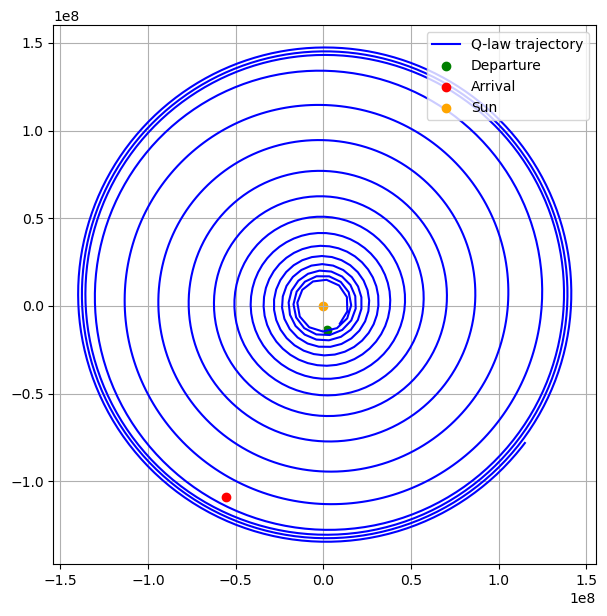

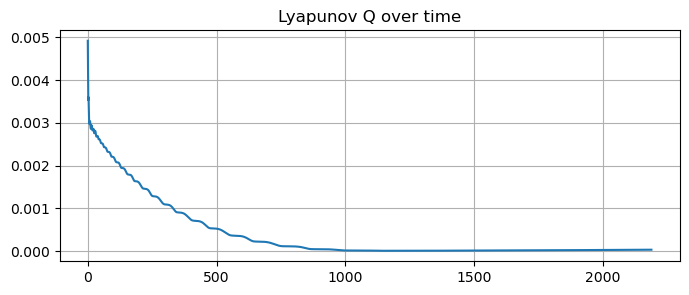

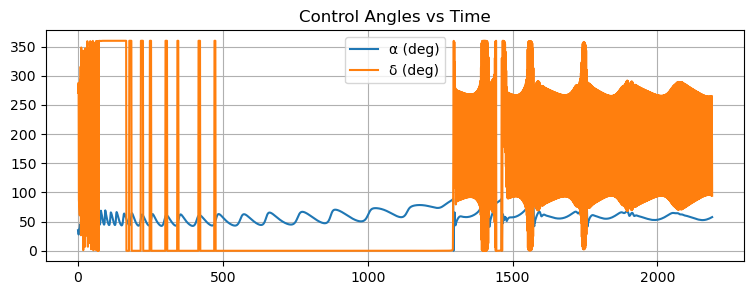

Saved sail_xy.gif and sail_yz.gif (6 frames, fps=6)


In [1]:
#!/usr/bin/env python3
"""
solar_sail_q_law_final_patched.py

Final Q-law solar sail simulation (GTOC13 planets).
Preserves your FD-based numeric B (stable),
adds:
  - RK45 integration with rtol/atol
  - Lyapunov (Q) diagnostics
  - α, δ debug prints
  - 2D + GIF visualization (yearly + monthly)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio, os, warnings
from tqdm import tqdm
from math import sin, cos, atan2, sqrt, pi
from scipy.integrate import solve_ivp

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -----------------------
# Constants and tuning
# -----------------------
MU_SUN = 1.32712440018e11
AU_KM = 1.49597870691e8
FD_DT = 10.0
EPS_A = 3.1e-7
W_P, W_F, W_G, W_H, W_K = 0.2, 5.0, 3.0, 0.3, 0.3
DELTA_P = 50.0 * AU_KM
DELTA_F, DELTA_G, DELTA_H, DELTA_K = 0.8, 0.8, np.radians(60), np.radians(90)
RTOL, ATOL = 1e-8, 1e-10

# -----------------------
# Helpers
# -----------------------
def norm(v): return np.linalg.norm(v)
def unit(v): return v / norm(v) if norm(v) > 0 else v * 0
def acos_safe(x): return np.arccos(np.clip(x, -1.0, 1.0))

# -----------------------
# Conversions
# -----------------------
def rv_to_kepler(r, v, mu=MU_SUN):
    r, v = np.array(r), np.array(v)
    h = np.cross(r, v); h_norm = norm(h)
    e_vec = np.cross(v, h)/mu - r/norm(r)
    e = norm(e_vec)
    energy = 0.5*norm(v)**2 - mu/norm(r)
    a = -mu/(2*energy)
    i = acos_safe(h[2]/(h_norm+1e-18))
    n_vec = np.cross([0,0,1], h); n = norm(n_vec)
    Omega = atan2(n_vec[1], n_vec[0]) if n > 1e-8 else 0
    if e > 1e-8:
        cos_nu = np.dot(e_vec, r)/(e*norm(r))
        nu = acos_safe(cos_nu)
        if np.dot(r, v) < 0: nu = 2*pi - nu
        omega = atan2(np.dot(np.cross(n_vec, e_vec), h)/h_norm, np.dot(n_vec, e_vec))
    else:
        omega, nu = 0, atan2(r[1], r[0])
    p = a*(1 - e**2)
    return {'a': a, 'e': e, 'i': i, 'Omega': Omega, 'omega': omega, 'nu': nu, 'p': p}

def kepler_to_mees(k):
    a, e, i, Omega, omega, nu = k['a'], k['e'], k['i'], k['Omega'], k['omega'], k['nu']
    p = a*(1 - e**2)
    f = e*cos(omega+Omega); g = e*sin(omega+Omega)
    h = np.tan(i/2)*cos(Omega); k_ = np.tan(i/2)*sin(Omega)
    L = (Omega + omega + nu) % (2*pi)
    return np.array([p, f, g, h, k_, L])

# -----------------------
# Q-law Lyapunov + gradient
# -----------------------
def compute_Q_and_grad(mees, target_mees):
    w = np.array([W_P, W_F, W_G, W_H, W_K])
    d = np.array([DELTA_P, DELTA_F, DELTA_G, DELTA_H, DELTA_K])
    invvars = 1.0/(w*d)
    diff = (mees[:5] - target_mees[:5]) * invvars
    Q = 0.5*np.sum(diff**2)
    grad = np.zeros(6); grad[:5] = diff * invvars
    return Q, grad

# -----------------------
# Numeric MEE dynamics
# -----------------------
def compute_mees_dot_numeric(r, v, a_rtn, dt=FD_DT):
    r_hat = unit(r); h_vec = np.cross(r, v); h_hat = unit(h_vec); t_hat = np.cross(h_hat, r_hat)
    a_inert = a_rtn[0]*r_hat + a_rtn[1]*t_hat + a_rtn[2]*h_hat
    r2 = r + v*dt
    v2 = v + (-MU_SUN*r/(norm(r)**3))*dt + a_inert*dt
    mee0 = kepler_to_mees(rv_to_kepler(r, v))
    mee2 = kepler_to_mees(rv_to_kepler(r2, v2))
    return (mee2 - mee0)/dt

def build_B_numeric(r, v):
    base = compute_mees_dot_numeric(r, v, np.zeros(3))
    B = np.zeros((6,3))
    for j in range(3):
        ap, an = np.zeros(3), np.zeros(3)
        ap[j], an[j] = EPS_A, -EPS_A
        B[:,j] = (compute_mees_dot_numeric(r, v, ap) - compute_mees_dot_numeric(r, v, an)) / (2*EPS_A)
    return B, base



# -----------------------
# Sail model
# -----------------------
def rtnd_basis(r, v):
    r_hat = unit(r)
    h_vec = np.cross(r, v); h_hat = unit(h_vec)
    t_hat = np.cross(h_hat, r_hat)
    return r_hat, t_hat, h_hat

def sail_normal_rtn(alpha, delta, r, v):
    r_hat, t_hat, h_hat = rtnd_basis(r, v)
    return unit(cos(alpha)*r_hat + sin(alpha)*cos(delta)*t_hat + sin(alpha)*sin(delta)*h_hat)

def sail_accel(alpha, delta, r, v, sail_params):
    n_hat = sail_normal_rtn(alpha, delta, r, v)
    r_hat = unit(r)
    cos_term = np.dot(n_hat, r_hat)
    if cos_term < 0: cos_term = 0
    r_AU = norm(r)/AU_KM
    P = sail_params['sail_C'] / (r_AU**2)
    a_m_s2 = (2*P*sail_params['sail_A']/sail_params['sail_m']) * (cos_term**2)
    return 1e-3 * a_m_s2 * n_hat

# def regularize_angles(alpha, delta, r, v, max_tilt_deg=90, sun_avoid_deg=0):
#     # prevent sail normal pointing into forbidden cone relative to sun-line
#     max_tilt = np.radians(max_tilt_deg)
#     sun_avoid = np.radians(sun_avoid_deg)
#     r_hat = unit(r); n_hat = sail_normal_rtn(alpha, delta, r, v)
#     cos_rn = np.dot(n_hat, r_hat)
#     if cos_rn < np.cos(sun_avoid):
#         # if it's pointing too close to anti-radial (i.e. too much illumination), feather
#         alpha = min(max_tilt, np.radians(89.0))
#     alpha = np.clip(alpha, 0.0, pi/2.0)
#     # alpha = np.clip(alpha, -pi/2.0, pi/2.0)
#     delta = float(delta % (2*pi))
#     return alpha, delta

def regularize_angles(alpha, delta):
    alpha = np.clip(alpha, 0, np.radians(89))
    delta = delta % (2*pi)
    return alpha, delta

# -----------------------
# g, c and debug
# -----------------------
def compute_g_and_c(r, v, target_mees, debug=False):
    mee = kepler_to_mees(rv_to_kepler(r, v))
    Q, grad = compute_Q_and_grad(mee, target_mees)
    B, D = build_B_numeric(r, v)
    g = B.T @ grad
    c = float(grad @ D)
    if debug:
        print(f"DEBUG: mee={np.round(mee[:5],6)}, g={np.round(g,6)}, Q={Q:.6e}")
    return g, c, Q

# -----------------------
# Optimal control
# -----------------------
def find_optimal_delta(g_t, g_n):
    return (atan2(g_n, g_t) + pi) % (2*pi)

def find_optimal_alpha(g_r, S):
    if S < 1e-10: return 0.0
    num = 3*g_r + np.sign(S)*np.sqrt(g_r**2 + 8*S**2)
    den = 4*S
    return np.arctan(np.clip(num/den, 0, np.tan(np.radians(89.9))))



# -----------------------
# RK45 with tolerance
# -----------------------
def rk45_step(r, v, alpha, delta, dt, sail_params):
    def f(t, y):
        r, v = y[:3], y[3:]
        a_grav = -MU_SUN * r / (norm(r)**3)
        a_sail = sail_accel(alpha, delta, r, v, sail_params)
        return np.hstack([v, a_grav + a_sail])
    sol = solve_ivp(f, [0, dt], np.hstack([r, v]), method='RK45', rtol=RTOL, atol=ATOL)
    return sol.y[:3,-1], sol.y[3:,-1]

# -----------------------
# Core simulation class
# -----------------------
class SolarSailSim:
    def __init__(self, planets_df):
        self.planets = planets_df
        self.sail_params = {'sail_C':5.4026e-6,'sail_A':1.5e4,'sail_m':500.0}
        self.bodies = {}
        for _, row in planets_df.iterrows():
            self.bodies[int(row['#Planet ID'])] = {
                'name': row['Name'], 'a': row['Semi-Major Axis (km)'],
                'e': row['Eccentricity ()'], 'i': np.radians(row['Inclination (deg)']),
                'Omega': np.radians(row['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(row['Argument of Periapsis (deg)']),
                'M0': np.radians(row['Mean Anomaly at t=0 (deg)'])
            }

    def get_state(self, body_id, t):
        b = self.bodies[body_id]
        a, e, i, Omega, omega, M0 = b['a'], b['e'], b['i'], b['Omega'], b['omega'], b['M0']
        n = np.sqrt(MU_SUN / a**3)
        M = (M0 + n*t) % (2*pi)
        E = M
        for _ in range(20): E -= (E - e*sin(E) - M)/(1 - e*cos(E))
        nu = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))
        r_mag = a*(1 - e*cos(E))
        r_pf = np.array([r_mag*cos(nu), r_mag*sin(nu), 0])
        v_pf = np.array([-sin(E), np.sqrt(1-e**2)*cos(E), 0]) * np.sqrt(MU_SUN*a)/(r_mag)
        R3W = np.array([[cos(Omega),-sin(Omega),0],[sin(Omega),cos(Omega),0],[0,0,1]])
        R1i = np.array([[1,0,0],[0,cos(i),-sin(i)],[0,sin(i),cos(i)]])
        R3w = np.array([[cos(omega),-sin(omega),0],[sin(omega),cos(omega),0],[0,0,1]])
        Q = R3W @ R1i @ R3w
        return Q@r_pf, Q@v_pf

    # def run_q_law(self, dep_id, arr_id, T_days=365*5, dt_hours=24):
    #     print(f"Simulating {self.bodies[dep_id]['name']} → {self.bodies[arr_id]['name']}")
    #     r0, v0 = self.get_state(dep_id, 0)
    #     rT, vT = self.get_state(arr_id, T_days*86400)
    #     target_mees = kepler_to_mees(rv_to_kepler(rT, vT))
    #     dt = dt_hours*3600; steps = int(T_days*24/dt_hours)
    #     r, v = r0.copy(), v0.copy()
    #     r_hist, alpha_hist, delta_hist, Q_hist, t_hist = [], [], [], [], []
    #     for k in tqdm(range(steps)):
    #         g, c, Q = compute_g_and_c(r, v, target_mees, debug=(k<3))
    #         g_r, g_t, g_n = g
    #         S = np.sqrt(g_t**2 + g_n**2)
    #         alpha = find_optimal_alpha(g_r, S)
    #         delta = find_optimal_delta(g_t, g_n)
    #         alpha, delta = regularize_angles(alpha, delta)
    #         if k < 3:
    #             print(f"Step {k}: α={np.degrees(alpha):.2f}°, δ={np.degrees(delta):.2f}°, Q={Q:.3e}")
    #         r, v = rk45_step(r, v, alpha, delta, dt, self.sail_params)
    #         r_hist.append(r); alpha_hist.append(alpha); delta_hist.append(delta); Q_hist.append(Q); t_hist.append(k*dt)
    #     return {'r':np.array(r_hist),'alpha':np.array(alpha_hist),
    #             'delta':np.array(delta_hist),'Q':np.array(Q_hist),
    #             't':np.array(t_hist),'r0':r0,'rT':rT}
    
    def run_q_law(self, dep_id, arr_id, T_days=365*5, dt_hours=24):
        print(f"Simulating {self.bodies[dep_id]['name']} → {self.bodies[arr_id]['name']}")
        r0, v0 = self.get_state(dep_id, 0)
        rT, vT = self.get_state(arr_id, T_days*86400)
        target_mees = kepler_to_mees(rv_to_kepler(rT, vT))

        dt = dt_hours * 3600
        steps = int(T_days * 24 / dt_hours)

        r, v = r0.copy(), v0.copy()
        r_hist, v_hist, alpha_hist, delta_hist, t_hist, Q_hist = [], [], [], [], [], []

        # --- get arrival planet radius ---
        R_arr = self.planets.loc[self.planets['#Planet ID'] == arr_id, 'Radius (km)'].values[0]
        flyby_found = False

        for k in tqdm(range(steps)):
            t = k * dt
            g, c, Q = compute_g_and_c(r, v, target_mees, debug=(k < 3))
            g_r, g_t, g_n = g
            S = np.sqrt(g_t**2 + g_n**2)
            alpha = find_optimal_alpha(g_r, S)
            delta = find_optimal_delta(g_t, g_n)
            alpha, delta = regularize_angles(alpha, delta)

            # integrate one step
            r, v = rk45_step(r, v, alpha, delta, dt, self.sail_params)

            # record
            r_hist.append(r)
            v_hist.append(v)
            alpha_hist.append(alpha)
            delta_hist.append(delta)
            t_hist.append(t)
            Q_hist.append(Q)

            # --- check flyby ---
            r_arr, v_arr = self.get_state(arr_id, t)
            rel_vec = r - r_arr
            rel_dist = np.linalg.norm(rel_vec)
            if (1.01 * R_arr) <= rel_dist <= (101.0 * R_arr):
                rel_vel = v - v_arr
                v_inf = np.linalg.norm(rel_vel)
                print(f"\n🚀 Flyby detected at t = {t/86400:.2f} days "
                    f"→ distance = {rel_dist/R_arr:.1f} R, v_inf = {v_inf:.3f} km/s")
                flyby_found = True
                break

        if not flyby_found:
            print("⚠️  No flyby detected within simulation duration.")

        data = {
            'r': np.array(r_hist),
            'v': np.array(v_hist),
            'alpha': np.array(alpha_hist),
            'delta': np.array(delta_hist),
            'Q': np.array(Q_hist),
            't': np.array(t_hist),
            'r0': r0,
            'rT': rT
        }
        return data


    def plot_trajectory(self, data, dep_id, arr_id):
        r_hist = data['r']; r0, rT = data['r0'], data['rT']
        plt.figure(figsize=(7,7))
        plt.plot(r_hist[:,0], r_hist[:,1], '-b', label='Q-law trajectory')
        plt.scatter(r0[0],r0[1],c='g',label='Departure')
        plt.scatter(rT[0],rT[1],c='r',label='Arrival')
        plt.scatter(0,0,c='orange',label='Sun')
        plt.axis('equal'); plt.legend(); plt.grid(); plt.show()

    def make_gif(self, data, dep_id, arr_id, yearly=True, fps=6, figsize=(6,6), dpi=120):
        """
        Create two synchronized GIFs (XY and YZ views) showing:
        - Spacecraft trajectory and current position
        - Departure and arrival planet positions (propagated)
        - Altaira (Sun) at origin
        """
        r_hist = data['r']
        t_hist = data['t']
        r0, rT = data['r0'], data['rT']

        # sampling
        step_seconds = t_hist[1] - t_hist[0]
        skip = int(365*24*3600/step_seconds) if yearly else int(30*24*3600/step_seconds)
        skip = max(1, skip)

        xy_frames, yz_frames = [], []
        for i in range(0, len(t_hist), skip):
            t = t_hist[i]
            r_sc = r_hist[i]

            # current planet states
            r_dep, _ = self.get_state(dep_id, t)
            r_arr, _ = self.get_state(arr_id, t)

            # ---- XY plane ----
            fig_xy, ax_xy = plt.subplots(figsize=figsize, dpi=dpi)
            ax_xy.plot(r_hist[:i,0], r_hist[:i,1], '-b', lw=1.5, label='Spacecraft')
            ax_xy.scatter(r_sc[0], r_sc[1], c='b', s=40, label='Spacecraft pos')
            ax_xy.scatter(r_dep[0], r_dep[1], c='g', s=50, label='Departure')
            ax_xy.scatter(r_arr[0], r_arr[1], c='r', s=50, label='Arrival')
            ax_xy.scatter(0, 0, c='orange', s=80, label='Altaira')
            ax_xy.set_xlabel('x (km)'); ax_xy.set_ylabel('y (km)')
            ax_xy.legend(loc='upper right', fontsize=7)
            ax_xy.set_title(f"XY Plane — t = {t/86400:.1f} days")
            lim = 1.2 * np.max(np.linalg.norm(r_hist, axis=1))
            ax_xy.set_xlim(-lim, lim); ax_xy.set_ylim(-lim, lim)
            ax_xy.grid(True)
            fig_xy.canvas.draw()
            xy_img = np.asarray(fig_xy.canvas.buffer_rgba())
            xy_frames.append(xy_img)
            plt.close(fig_xy)

            # ---- YZ plane ----
            fig_yz, ax_yz = plt.subplots(figsize=figsize, dpi=dpi)
            ax_yz.plot(r_hist[:i,1], r_hist[:i,2], '-b', lw=1.5)
            ax_yz.scatter(r_sc[1], r_sc[2], c='b', s=40)
            ax_yz.scatter(r_dep[1], r_dep[2], c='g', s=50)
            ax_yz.scatter(r_arr[1], r_arr[2], c='r', s=50)
            ax_yz.scatter(0, 0, c='orange', s=80)
            ax_yz.set_xlabel('y (km)'); ax_yz.set_ylabel('z (km)')
            ax_yz.set_title(f"YZ Plane — t = {t/86400:.1f} days")
            ax_yz.set_xlim(-0.3*lim, 0.3*lim); ax_yz.set_ylim(-0.3*lim, 0.3*lim)
            ax_yz.grid(True)
            fig_yz.canvas.draw()
            yz_img = np.asarray(fig_yz.canvas.buffer_rgba())
            yz_frames.append(yz_img)
            plt.close(fig_yz)
        
        # write gifs
        xy_gif = "sail_xy.gif" if yearly else "sail_xy_monthly.gif"
        yz_gif = "sail_yz.gif" if yearly else "sail_yz_monthly.gif"

        imageio.mimsave(xy_gif, xy_frames, fps=fps)
        imageio.mimsave(yz_gif, yz_frames, fps=fps)
        print(f"Saved {xy_gif} and {yz_gif} ({len(xy_frames)} frames, fps={fps})")

# -----------------------
# Runner
# -----------------------
if __name__ == "__main__":
    planets = pd.read_csv("gtoc13_planets.csv", encoding='latin1')
    sim = SolarSailSim(planets)
    data = sim.run_q_law(dep_id=1, arr_id=2, T_days=365*6, dt_hours=24)
    sim.plot_trajectory(data, dep_id=1, arr_id=2)

    # Diagnostics plots
    t_days = data['t']/86400
    plt.figure(figsize=(8,3)); plt.plot(t_days, data['Q']); plt.grid(); plt.title("Lyapunov Q over time"); plt.show()
    plt.figure(figsize=(9,3))
    plt.plot(t_days, np.degrees(data['alpha']), label='α (deg)')
    plt.plot(t_days, np.degrees(data['delta']), label='δ (deg)')
    plt.legend(); plt.grid(); plt.title("Control Angles vs Time"); plt.show()

    # Optional GIF
    sim.make_gif(data, dep_id=1, arr_id=2, yearly=True)
